<a href="https://colab.research.google.com/github/Lyanan85/In-GameSeries/blob/venv/notebook_groupby.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Criando tabulações com groupby**


###**Carregando os dados**

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/alura-cursos/python_dados/refs/heads/main/Dados/contagem_bicicletas.csv')

Neste conjunto de dados, temos informações sobre uma empresa que realiza o aluguel de bicicletas. O DataFrame contém registros detalhados, como o número de bicicletas alugadas por dia e horário, condições climáticas e informações sobre finais feriados e finais de semana:


In [3]:
df.head()

,data_hora,contagem,temperatura,sensacao_termica,umidade,velocidade_vento,clima,feriado,fim_de_semana,estacao
0,2015-01-04 00:00:00,182,3.00,2.00,93.0,6.0,Nublado,Não,Sim,Inverno
1,2015-01-04 01:00:00,138,2.75,2.25,93.0,5.0,Céu limpo,Não,Sim,Inverno
2,2015-01-04 02:00:00,134,2.50,2.50,96.5,0.0,Céu limpo,Não,Sim,Inverno
3,2015-01-04 03:00:00,72,2.00,2.00,100.0,0.0,Céu limpo,Não,Sim,Inverno
4,2015-01-04 04:00:00,47,2.00,2.00,93.0,6.5,Céu limpo,Não,Sim,Inverno


###**Utilizando o método groupby**

O método [`groupby()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html) da biblioteca pandas é fundamental quando precisamos agrupar os dados com base em uma ou mais colunas e calcular estatísticas ou aplicar métodos específicos a esses grupos.

Essa abordagem nos ajuda a organizar e resumir os dados de maneira eficiente, facilitando a análise e a visualização dos padrões que desejamos explorar.

Neste exemplo, agrupamos os dados baseados na coluna `clima `e usamos o método `describe()` para obter um resumo estatístico da coluna `contagem`. Isso inclui estatísticas descritivas como contagem, média, desvio padrão, mínimo, máximo, e os quartis, proporcionando uma visão detalhada das características dos dados agrupados por clima:


In [4]:
estatisticas_clima = df.groupby('clima')['contagem'].describe()
estatisticas_clima

,count,mean,std,min,25%,50%,75%,max
clima,,,,,,,,
Chuva com trovoadas,14.0,583.428571,283.001689,150.0,302.00,620.5,765.00,1040.0
Chuva leve,2141.0,712.966371,764.879409,0.0,150.00,471.0,981.00,6585.0
Céu limpo,6150.0,1162.088943,1187.218019,10.0,196.00,745.0,1767.00,7860.0
Neve,60.0,250.850000,470.588878,15.0,38.25,88.0,192.00,2894.0
Nublado,3551.0,1195.124472,1014.745557,12.0,430.00,964.0,1673.50,5033.0
Parcialmente nublado,5498.0,1266.925791,1076.500198,14.0,373.00,1050.5,1805.75,7531.0


Também temos a opção de executar operações específicas! Utilizando o método `groupby()`, podemos aplicar uma variedade de funções de agregação para resumir os dados de maneiras diferentes. Aqui estão as funções que podem ser usadas com `groupby()`:

- `count()` para realizar contagem
- `sum()` para soma
- `mean()` para a média
- `median()` para a mediana
- `min()` para o valor mínimo
- `max()` para o valor máximo
- `std()` para o desvio-padrão
- `var()` para a variância

A seguir, vamos aplicar a função de soma `sum()`:

In [5]:
soma_clima = df.groupby('clima')['contagem'].sum()
soma_clima

,contagem
clima,
Chuva com trovoadas,8168
Chuva leve,1526461
Céu limpo,7146847
Neve,15051
Nublado,4243887
Parcialmente nublado,6965558


Podemos ordenar os dados para tornar a análise mais clara e intuitiva, com uso do método `sort_values(ascending=False)`:

In [6]:
soma_clima = df.groupby('clima')['contagem'].sum().sort_values(ascending=False)
soma_clima

,contagem
clima,
Céu limpo,7146847
Parcialmente nublado,6965558
Nublado,4243887
Chuva leve,1526461
Neve,15051
Chuva com trovoadas,8168


Se quisermos realizar mais de um tipo de cálculo, como somar, calcular a média, o mínimo e o máximo, podemos usar o método `agg()`:


In [7]:
soma_clima = df.groupby('clima')['contagem'].agg(['sum', 'mean', 'min', 'max'])
soma_clima

,sum,mean,min,max
clima,,,,
Chuva com trovoadas,8168,583.428571,150,1040
Chuva leve,1526461,712.966371,0,6585
Céu limpo,7146847,1162.088943,10,7860
Neve,15051,250.850000,15,2894
Nublado,4243887,1195.124472,12,5033
Parcialmente nublado,6965558,1266.925791,14,7531


Além disso, também é possível agrupar os dados por mais de uma variável. No exemplo abaixo, estamos agrupando pelas colunas `estacao` e `clima`:

In [8]:
df_estacao_clima = df.groupby(['estacao', 'clima'])['contagem'].mean()
df_estacao_clima

estacao    clima               
Inverno    Chuva com trovoadas      228.000000
           Chuva leve               542.968153
           Céu limpo                760.163115
           Neve                     318.409091
           Nublado                  971.990635
           Parcialmente nublado     908.796070
Outono     Chuva com trovoadas      242.000000
           Chuva leve               788.809249
           Céu limpo               1130.973451
           Neve                      59.300000
           Nublado                 1281.383778
           Parcialmente nublado    1304.220484
Primavera  Chuva com trovoadas      798.428571
           Chuva leve               677.873162
           Céu limpo               1144.472603
           Neve                      74.666667
           Nublado                 1162.028607
           Parcialmente nublado    1199.101483
Verão      Chuva com trovoadas      421.800000
           Chuva leve               905.160000
           Céu limpo               1471.312843
           Nublado                 1393.618065
           Parcialmente nublado    1688.683146
Name: contagem, dtype: float64

>
👩‍💻***Dica da Val:*** Caso você queira visualizar os resultados do agrupamento em formato de tabela, pode usar o método [`unstack()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.unstack.html) para transformar o índice hierárquico em colunas:

In [9]:
df_estacao_clima_unstack = df_estacao_clima.unstack()
df_estacao_clima_unstack

clima,Chuva com trovoadas,Chuva leve,Céu limpo,Neve,Nublado,Parcialmente nublado
estacao,,,,,,
Inverno,228.000000,542.968153,760.163115,318.409091,971.990635,908.796070
Outono,242.000000,788.809249,1130.973451,59.300000,1281.383778,1304.220484
Primavera,798.428571,677.873162,1144.472603,74.666667,1162.028607,1199.101483
Verão,421.800000,905.160000,1471.312843,NaN,1393.618065,1688.683146


E se quisermos diferentes agregações em um agrupamento múltiplo?
Quando trabalhamos com várias colunas, podemos aplicar diferentes funções de agregação a cada uma delas, criando um dicionário que especifica as funções desejadas para cada coluna:

In [10]:
agregacoes = {
    'contagem': 'sum',
    'temperatura': 'mean',
    'sensacao_termica': 'mean',
    'umidade': 'mean'
}

df_agregacoes = df.groupby(['estacao', 'clima']).agg(agregacoes)
df_agregacoes

contagem  temperatura  sensacao_termica  \
estacao   clima                                                           
Inverno   Chuva com trovoadas        228    10.000000          6.500000   
          Chuva leve              340984     9.046576          7.188296   
          Céu limpo               927399     6.022336          3.811066   
          Neve                     14010     4.375000          1.568182   
          Nublado                 934083     8.754422          7.008585   
          Parcialmente nublado   1341383     7.887873          5.933096   
Outono    Chuva com trovoadas        242    18.500000         18.500000   
          Chuva leve              409392    12.830443         12.222543   
          Céu limpo              1533600    12.233776         11.516962   
          Neve                       593     7.400000          3.800000   
          Nublado                1295479    13.689416         13.331355   
          Parcialmente nublado   1833734    13.461830         13.035799   
Primavera Chuva com trovoadas       5589     9.785714          7.785714   
          Chuva leve              368763    10.186581          8.657169   
          Céu limpo              2005116    10.843322          9.775970   
          Neve                       448     7.833333          5.083333   
          Nublado                 934271    10.582090          9.302861   
          Parcialmente nublado   1536049    10.700234          9.370414   
Verão     Chuva com trovoadas       2109    18.200000         18.200000   
          Chuva leve              407322    17.065556         17.064444   
          Céu limpo              2680732    18.930845         18.855653   
          Nublado                1080054    17.558710         17.545806   
          Parcialmente nublado   2254392    18.716854         18.685393   

                                  umidade  
estacao   clima                            
Inverno   Chuva com trovoadas   88.000000  
          Chuva leve            83.739650  
          Céu limpo             76.006148  
          Neve                  87.829545  
          Nublado               78.369927  
          Parcialmente nublado  76.405149  
Outono    Chuva com trovoadas   91.000000  
          Chuva leve            84.075145  
          Céu limpo             74.282448  
          Neve                  91.550000  
          Nublado               78.105341  
          Parcialmente nublado  73.333926  
Primavera Chuva com trovoadas   63.071429  
          Chuva leve            80.169118  
          Céu limpo             64.142694  
          Neve                  91.250000  
          Nublado               73.543532  
          Parcialmente nublado  66.598556  
Verão     Chuva com trovoadas   85.500000  
          Chuva leve            81.085556  
          Céu limpo             61.675906  
          Nublado               73.968387  
          Parcialmente nublado  64.894757

>
👩‍💻***Dica da Val:*** Após a agregação, podemos renomear as colunas para torná-las mais descritivas e intuitivas.

Isso poderia ser feito da seguinte forma:
```python
df_agregacoes.rename(columns={
    'contagem': 'total_contagem',
    'temperatura': 'media_temperatura',
    'sensacao_termica': 'media_sensacao_termica',
    'umidade': 'media_umidade'
}, inplace=True)
```

Com o `groupby()` conseguimos realizar diversas análises para extrair insights importantes sobre os dados.

Desde sumarizar informações, até combinar múltiplos cálculos em um agrupamento, essas técnicas são extremamente poderosas para análises exploratórias e para entender os padrões presentes no conjunto de dados.




In [14]:
url="https://raw.githubusercontent.com/alura-cursos/python_dados/refs/heads/main/Dados/loja_vendas.csv"
df=pd.read_csv(url)
df

,ID_compra,unidade,cidade,data,horario,categoria_produto,valor_unitario,quantidade,valor_total,metodo_pagamento,ID_cliente,programa_cashback,idade,avaliacao_compra
0,6,Parque das nações,Santo André,2022-01-03,15:40,Eletrônicos,4457.9,4,17831.6,Dinheiro,6149,Sim,30,10
1,5,Oswaldo Cruz,São Caetano do Sul,2022-01-03,16:48,Ferramentas e construção,115.9,1,115.9,PIX,9491,Sim,36,9
2,9,Paulicéia,São Bernardo do Campo,2022-01-03,12:08,Beleza e cuidados pessoais,68.9,2,137.8,Cartão,5288,Não,39,9
3,4,Oswaldo Cruz,São Caetano do Sul,2022-01-03,9:29,Ferramentas e construção,80.9,5,404.5,PIX,9679,Sim,35,10
4,8,Parque das nações,Santo André,2022-01-03,13:02,Beleza e cuidados pessoais,165.0,4,660.0,PIX,1380,Não,50,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6164,6141,Oswaldo Cruz,São Caetano do Sul,2022-12-31,12:49,Eletrônicos,1509.9,5,7549.5,Cartão,6035,Não,49,10
6165,6148,Paulicéia,São Bernardo do Campo,2022-12-31,18:02,Papelaria e escritório,14.0,2,28.0,PIX,7361,Sim,40,9
6166,6123,Paulicéia,São Bernardo do Campo,2022-12-31,16:25,Alimentos e bebidas,77.9,1,77.9,Cartão,4516,Não,32,8
6167,6147,Oswaldo Cruz,São Caetano do Sul,2022-12-31,16:38,Livros,142.9,4,571.6,Cartão,3786,Não,34,10


In [16]:
df.groupby("unidade")["valor_total"].sum().reset_index()

,unidade,valor_total
0,Oswaldo Cruz,5811213.0
1,Parque das nações,5443778.1
2,Paulicéia,4988462.9


In [19]:
df=pd.read_csv("https://raw.githubusercontent.com/alura-cursos/python_dados/refs/heads/main/Dados/loja_vendas.csv")
df.head()

,ID_compra,unidade,cidade,data,horario,categoria_produto,valor_unitario,quantidade,valor_total,metodo_pagamento,ID_cliente,programa_cashback,idade,avaliacao_compra
0,6,Parque das nações,Santo André,2022-01-03,15:40,Eletrônicos,4457.9,4,17831.6,Dinheiro,6149,Sim,30,10
1,5,Oswaldo Cruz,São Caetano do Sul,2022-01-03,16:48,Ferramentas e construção,115.9,1,115.9,PIX,9491,Sim,36,9
2,9,Paulicéia,São Bernardo do Campo,2022-01-03,12:08,Beleza e cuidados pessoais,68.9,2,137.8,Cartão,5288,Não,39,9
3,4,Oswaldo Cruz,São Caetano do Sul,2022-01-03,9:29,Ferramentas e construção,80.9,5,404.5,PIX,9679,Sim,35,10
4,8,Parque das nações,Santo André,2022-01-03,13:02,Beleza e cuidados pessoais,165.0,4,660.0,PIX,1380,Não,50,9


In [21]:
df.groupby("categoria_produto")["valor_total"].sum().sort_values(ascending=False)

,valor_total
categoria_produto,
Eletrônicos,14898778.5
Beleza e cuidados pessoais,423262.9
Casa e limpeza,316688.6
Ferramentas e construção,252953.1
Alimentos e bebidas,231284.3
Livros,75265.0
Papelaria e escritório,45221.6


In [29]:
df.groupby("metodo_pagamento")["idade"].agg(["mean","min","max"]).round().reset_index()

,metodo_pagamento,mean,min,max
0,Carteira digital,28.0,18,60
1,Cartão,38.0,18,65
2,Dinheiro,46.0,18,70
3,PIX,40.0,18,68


In [34]:
url="https://raw.githubusercontent.com/alura-cursos/python_dados/refs/heads/main/Dados/apartamentos_aluguel.csv"
df=pd.read_csv(url)
df.head()

,Quartos,Banheiros,Suites,Vagas,Elevador,Mobiliado,Piscina,Regiao,Ano,Valor
0,2,2,1,1,Nao,Nao,Sim,Centro,2015,2500
1,1,2,1,2,Sim,Sim,Sim,Centro,2019,5000
2,1,2,1,1,Sim,Sim,Nao,Centro,2007,1600
3,2,2,1,1,Nao,Nao,Nao,Centro,2008,1500
4,3,3,1,1,Sim,Nao,Nao,Centro,2009,2200


In [40]:
df.groupby("Regiao")["Valor"].describe().round().reset_index()

,Regiao,count,mean,std,min,25%,50%,75%,max
0,Centro,882.0,3002.0,1525.0,630.0,1650.0,2500.0,4279.0,7000.0
1,Leste,1918.0,1697.0,830.0,480.0,1100.0,1450.0,2000.0,5025.0
2,Norte,1264.0,1995.0,1011.0,500.0,1250.0,1600.0,2500.0,5652.0
3,Oeste,1779.0,3590.0,2058.0,800.0,2000.0,3000.0,4700.0,10100.0
4,Sul,1809.0,2977.0,1717.0,700.0,1600.0,2500.0,4000.0,7800.0


In [43]:
df.head()

,Quartos,Banheiros,Suites,Vagas,Elevador,Mobiliado,Piscina,Regiao,Ano,Valor
0,2,2,1,1,Nao,Nao,Sim,Centro,2015,2500
1,1,2,1,2,Sim,Sim,Sim,Centro,2019,5000
2,1,2,1,1,Sim,Sim,Nao,Centro,2007,1600
3,2,2,1,1,Nao,Nao,Nao,Centro,2008,1500
4,3,3,1,1,Sim,Nao,Nao,Centro,2009,2200


In [52]:
df.groupby(["Regiao","Piscina"])["Valor"].mean()

Regiao  Piscina
Centro  Nao        2723.148900
        Sim        3566.979381
Leste   Nao        1528.108367
        Sim        2017.036199
Norte   Nao        1780.965217
        Sim        2252.062718
Oeste   Nao        3261.135101
        Sim        3854.184397
Sul     Nao        2549.529851
        Sim        3318.285572
Name: Valor, dtype: float64

In [56]:
df.groupby(["Regiao","Piscina"])["Valor"].mean().unstack().reset_index()

Piscina,Regiao,Nao,Sim
0,Centro,2723.148900,3566.979381
1,Leste,1528.108367,2017.036199
2,Norte,1780.965217,2252.062718
3,Oeste,3261.135101,3854.184397
4,Sul,2549.529851,3318.285572


In [57]:
df.head(1)

,Quartos,Banheiros,Suites,Vagas,Elevador,Mobiliado,Piscina,Regiao,Ano,Valor
0,2,2,1,1,Nao,Nao,Sim,Centro,2015,2500


In [62]:
anos=df.groupby("Ano")["Valor"].mean().reset_index()
anos

,Ano,Valor
0,1998,955.798701
1,1999,1059.437229
2,2000,1110.494662
3,2001,1167.624224
4,2002,1267.341463
5,2003,1364.223368
6,2004,1443.289157
7,2005,1545.721854
8,2006,1594.024242
9,2007,1750.520270


<Axes: >

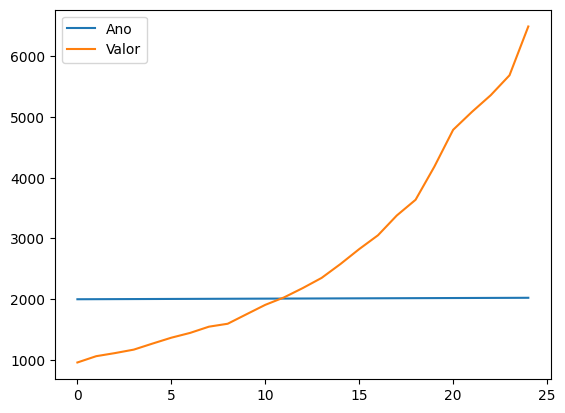

In [65]:
anos.plot(kind="line")

In [67]:
url="https://raw.githubusercontent.com/alura-cursos/python_dados/refs/heads/main/Dados/pacientes_doenca_cardiaca.csv"
df=pd.read_csv(url)
df.head()

,Idade,Sexo_biologico,Tipo_dor,Pressao_arterial,Colesterol,Glicemia_jejum>120,Resultados_ECG,Frequencia_cardiaca_max,Dor_exercicio,Depressao_ST,Inclinacao_ST,Numero_vasos_fluro,Teste_cintilografia,Doenca_cardiaca
0,70,Masculino,assintomática,130,322,Não,2,109,Não,2.4,2,3,3,Sim
1,67,Feminino,dor não anginosa,115,564,Não,2,160,Não,1.6,2,0,7,Não
2,57,Masculino,angina atípica,124,261,Não,0,141,Não,0.3,1,0,7,Sim
3,64,Masculino,assintomática,128,263,Não,0,105,Sim,0.2,2,1,7,Não
4,74,Feminino,angina atípica,120,269,Não,2,121,Sim,0.2,1,1,3,Não


In [74]:
df.groupby(["Sexo_biologico","Doenca_cardiaca"])['Idade'].agg(["min","mean","max"]).round().reset_index()

,Sexo_biologico,Doenca_cardiaca,min,mean,max
0,Feminino,Não,34,55.0,76
1,Feminino,Sim,43,59.0,66
2,Masculino,Não,29,51.0,70
3,Masculino,Sim,35,56.0,77


In [84]:
df.groupby(["Doenca_cardiaca","Tipo_dor"])["Depressao_ST"].mean()

Doenca_cardiaca  Tipo_dor        
Não              angina atípica      0.277143
                 angina típica       1.426667
                 assintomática       0.581579
                 dor não anginosa    0.648387
Sim              angina atípica      0.642857
                 angina típica       1.600000
                 assintomática       1.639560
                 dor não anginosa    1.670588
Name: Depressao_ST, dtype: float64

In [85]:
df.groupby(["Doenca_cardiaca","Tipo_dor"])["Depressao_ST"].mean().unstack()

Tipo_dor,angina atípica,angina típica,assintomática,dor não anginosa
Doenca_cardiaca,,,,
Não,0.277143,1.426667,0.581579,0.648387
Sim,0.642857,1.600000,1.639560,1.670588


In [88]:
df.head(1)

,Idade,Sexo_biologico,Tipo_dor,Pressao_arterial,Colesterol,Glicemia_jejum>120,Resultados_ECG,Frequencia_cardiaca_max,Dor_exercicio,Depressao_ST,Inclinacao_ST,Numero_vasos_fluro,Teste_cintilografia,Doenca_cardiaca
0,70,Masculino,assintomática,130,322,Não,2,109,Não,2.4,2,3,3,Sim


In [91]:
df.groupby(["Doenca_cardiaca","Sexo_biologico"])[["Idade","Colesterol","Frequencia_cardiaca_max","Depressao_ST","Inclinacao_ST","Numero_vasos_fluro"]].mean().reset_index()

,Doenca_cardiaca,Sexo_biologico,Idade,Colesterol,Frequencia_cardiaca_max,Depressao_ST,Inclinacao_ST,Numero_vasos_fluro
0,Não,Feminino,54.582090,257.208955,154.835821,0.568657,1.402985,0.313433
1,Não,Masculino,51.192771,233.722892,161.156627,0.666265,1.397590,0.265060
2,Sim,Feminino,59.350000,290.000000,143.500000,1.960000,2.000000,1.350000
3,Sim,Masculino,56.040000,249.760000,137.930000,1.509000,1.780000,1.110000
